In [16]:
## 2026.05.18 using FineST env
##            load Xenium annotation data
##            - the annotation form transcriptomic - 
##            - Select4: VUHD113, VUILD107MA, VUILD102LA, VUILD96LA
##            - HE cells: built from Weiqin cells_partitioned_by_annotation.csv (see SELECT4_SAMPLES)
##            - Lu help run Star_Dist - data/Xemium/LUNG/StarDist_Segment/
## 2026.05.19 VUHD113- VUILD107MA- VUILD102LA- VUILD96LA

In [4]:
# cd /home/lingyu/ssd2/Python/Hist2Pheno
# bash code/Xenium_lung/demo_VUILD107MA.sh
# bash code/Xenium_lung/demo_VUILD102LA.sh
# bash code/Xenium_lung/demo_VUILD96LA.sh

In [1]:
## for AI edit
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

## Add the code directory to Python path
path = '/home/lingyu/ssd2/Python/'
import os
os.chdir(f'{path}Hist2Pheno/data/')
!pwd


## Load function
import sys
from pathlib import Path
_xenium_dir = Path("/home/lingyu/ssd2/Python/Hist2Pheno/code/Xenium_lung")
if str(_xenium_dir) not in sys.path:
    sys.path.insert(0, str(_xenium_dir))
from plot_spatial_he_labels import plot_spatial_he_maps, DEFAULT_FIGURES_DIR

/ssd2/users/lingyu/Python/Collaborate/esccAI/data


### Load annotation for niche and tissue
Load data from Weiqin
- /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Annotation/HE_Annotations

In [2]:
import pandas as pd
csv_path_weiqin = f'{path}Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Annotation/HE_Annotations/cells_partitioned_by_annotation.csv'
df_weiqin = pd.read_csv(csv_path_weiqin)
df_weiqin

,sample,full_cell_id,cell_id,annotation_type_instance,annotation_type,annotation_instance,Annotation_Type,num_cells_annotation_type_instance,x_centroid,y_centroid,CNiche,TNiche,final_CT,final_lineage,final_sublineage,tma
0,VUHD116A,VUHD116A_aaaaaacg-1,aaaaaacg-1,normal_alveoli_2,normal_alveoli,2,Normal Alveoli,740,1663.692175,82.937963,C8,T4,SMCs/Pericytes,Mesenchymal,Mesenchymal,TMA1
1,VUHD116A,VUHD116A_aaaaaacl-1,aaaaaacl-1,normal_alveoli_2,normal_alveoli,2,Normal Alveoli,740,1669.976282,382.249965,C8,T4,Capillary,Endothelial,Endothelial,TMA1
2,VUHD116A,VUHD116A_aaaaaacp-1,aaaaaacp-1,normal_alveoli_3,normal_alveoli,2,Normal Alveoli,1512,2496.735547,757.727945,C8,T4,Alveolar FBs,Mesenchymal,Mesenchymal,TMA1
3,VUHD116A,VUHD116A_aaaaaadb-1,aaaaaadb-1,normal_alveoli_2,normal_alveoli,2,Normal Alveoli,740,1644.208582,73.882906,C8,T4,Capillary,Endothelial,Endothelial,TMA1
4,VUHD116A,VUHD116A_aaaaaadc-1,aaaaaadc-1,normal_alveoli_2,normal_alveoli,2,Normal Alveoli,740,1658.244061,379.432784,C8,T4,Capillary,Endothelial,Endothelial,TMA1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
790929,VUILD58,VUILD58_ofeondlc-1,ofeondlc-1,muscularized_artery_2,muscularized_artery,3,Muscularized Artery,359,2280.139160,3853.644531,C4,T6,Myofibroblasts,Mesenchymal,Mesenchymal,TMA5
790930,VUILD58,VUILD58_ofeooakp-1,ofeooakp-1,muscularized_artery_2,muscularized_artery,3,Muscularized Artery,359,2279.693359,3816.789795,C4,T9,Alveolar FBs,Mesenchymal,Mesenchymal,TMA5
790931,VUILD58,VUILD58_ofeoonjb-1,ofeoonjb-1,muscularized_artery_2,muscularized_artery,3,Muscularized Artery,359,2317.959961,3853.163086,C4,T9,Alveolar FBs,Mesenchymal,Mesenchymal,TMA5
790932,VUILD58,VUILD58_offoldom-1,offoldom-1,muscularized_artery_2,muscularized_artery,3,Muscularized Artery,359,2375.071533,3974.686768,C4,T6,Alveolar FBs,Mesenchymal,Mesenchymal,TMA5


In [5]:
print('Total samples:', len(df_weiqin['sample'].unique()))


Total samples: 45


In [3]:
## show the unique counts of each column
label_cols = ['CNiche', 'TNiche', 'final_CT', 'final_lineage', 'final_sublineage']
for col in label_cols:
    vc = df_weiqin[col].value_counts(dropna=False)
    print(f"\n=== {col} === ({vc.shape[0]} unique, n={len(df_weiqin):,}) ===")
    print(vc.to_string())


=== CNiche === (12 unique, n=790,934) ===
CNiche
C8     212045
C4     142169
C3     115892
C1      85169
C9      80558
C12     41067
C11     23559
C6      23205
C7      21312
C5      17629
C2      15060
C10     13269

=== TNiche === (12 unique, n=790,934) ===
TNiche
T4     153132
T9     105261
T5     102206
T2      93264
T6      55880
T7      51554
T3      45026
T11     42044
T10     41941
T12     37869
T1      31577
T8      31180

=== final_CT === (47 unique, n=790,934) ===
final_CT
Alveolar FBs                   102202
Capillary                       77556
SMCs/Pericytes                  59120
Interstitial Macrophages        58966
AT2                             51986
CD4+ T-cells                    44321
Venous                          39264
Multiciliated                   31377
Plasma                          28505
CD8+ T-cells                    26314
B cells                         25685
Activated Fibrotic FBs          22351
Neutrophils                     19337
Basal           

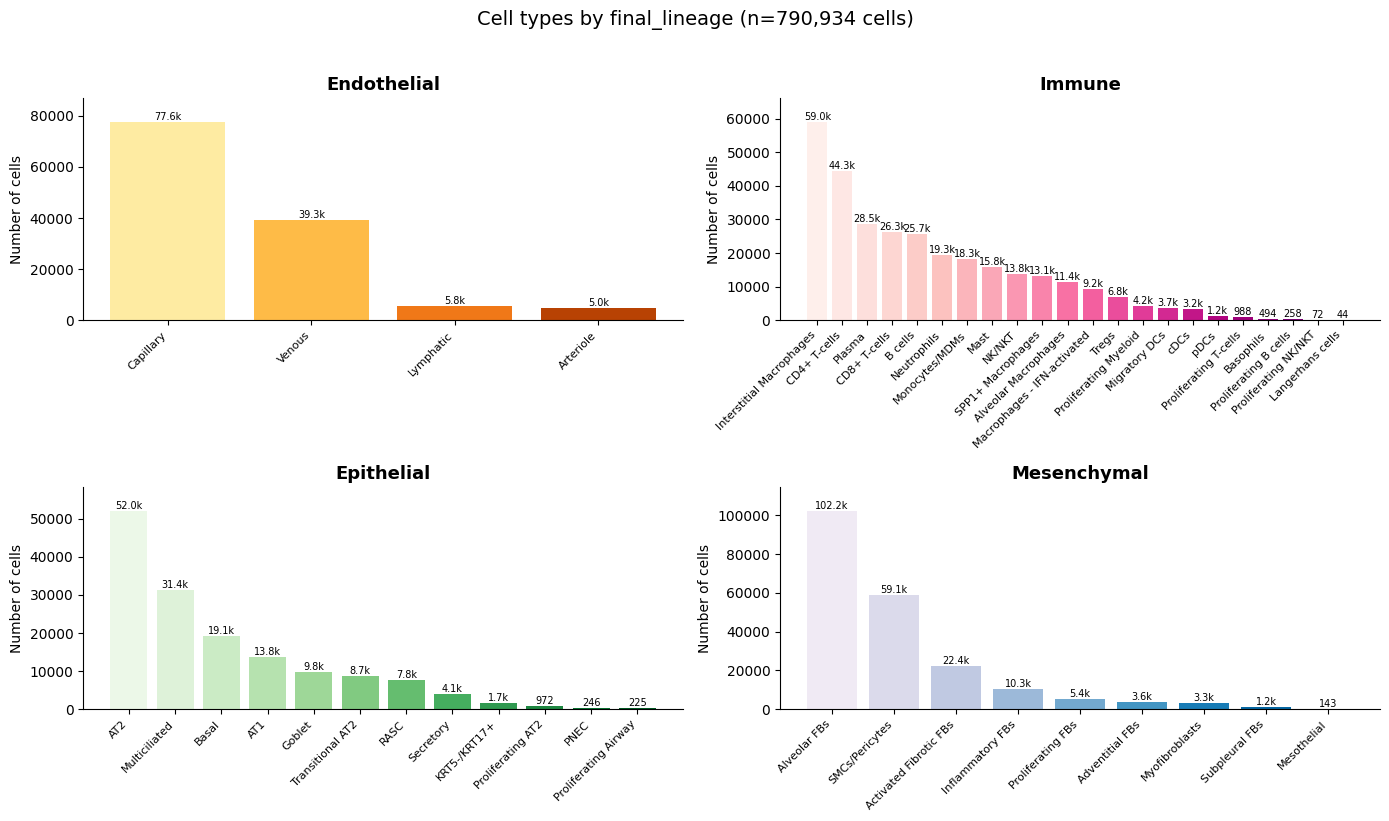

In [14]:
# Bar plots: cell-type counts within each lineage (paper-style 2x2)
import importlib
import plot_spatial_he_labels
importlib.reload(plot_spatial_he_labels)
from plot_spatial_he_labels import plot_final_ct_by_lineage

ct_by_lineage_out = (
    f"{path}Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/"
    "Spatial-PF-Processed/Annotation/HE_Annotations/LLY_annotation/Figures/"
    "final_CT_by_lineage.pdf"
)

lineage_col = "final_lineage"
ct_col = "final_CT"

plot_final_ct_by_lineage(
    df_weiqin,
    lineage_col=lineage_col,
    ct_col=ct_col,
    figsize = (14,8),
    save_path = None,
    # save_path = ct_by_lineage_out,
    title=f"Cell types by {lineage_col} (n={len(df_weiqin):,} cells)",
)

In [ ]:
df = df_weiqin

print("=== SHAPE ===")
print(f"Rows: {len(df_weiqin):,}, Cols: {len(df_weiqin.columns)}")

print("\n=== UNIQUE COUNTS ===")
for col in df_weiqin.columns:
    print(f"  {col}: {df[col].nunique()} unique")

print("\n=== SAMPLES ===")
n_samples = df['sample'].nunique()
print(f"Number of samples: {n_samples}")
samples = sorted(df['sample'].unique())
print("Samples:", samples)

print("\n=== CELLS PER SAMPLE ===")
cpc = df_weiqin.groupby('sample').size().sort_values(ascending=False)
print(cpc.to_string())
print("\nStats:", cpc.describe().to_string())

print("\n=== TMA ===")
print(df['tma'].value_counts().to_string())

print("\n=== annotation_type ===")
print(df['annotation_type'].value_counts().to_string())

print("\n=== Annotation_Type ===")
print(df['Annotation_Type'].value_counts().to_string())

print("\n=== final_lineage ===")
print(df['final_lineage'].value_counts().to_string())

print("\n=== final_CT ===")
print(df['final_CT'].value_counts().to_string())

print("\n=== CNiche ===")
print(df['CNiche'].value_counts().to_string())

print("\n=== TNiche ===")
print(df['TNiche'].value_counts().to_string())

print("\n=== Duplicates ===")
print("full_cell_id dups:", df['full_cell_id'].duplicated().sum())


=== SHAPE ===
Rows: 790,934, Cols: 16

=== UNIQUE COUNTS ===
  sample: 45 unique
  full_cell_id: 770092 unique
  cell_id: 240486 unique
  annotation_type_instance: 152 unique
  annotation_type: 25 unique
  annotation_instance: 5 unique
  Annotation_Type: 25 unique
  num_cells_annotation_type_instance: 439 unique
  x_centroid: 760799 unique
  y_centroid: 760823 unique
  CNiche: 12 unique
  TNiche: 12 unique
  final_CT: 47 unique
  final_lineage: 4 unique
  final_sublineage: 6 unique
  tma: 5 unique

=== SAMPLES ===
Number of samples: 45
Samples: ['THD0008', 'THD0011', 'TILD028MF', 'TILD049LF', 'TILD080MF', 'TILD111LF', 'TILD113MF', 'TILD117LF', 'TILD117MF', 'TILD117MFB', 'TILD130MF', 'TILD167LF', 'TILD175', 'TILD299LF', 'TILD315LF', 'VUHD038', 'VUHD049', 'VUHD069', 'VUHD090', 'VUHD095', 'VUHD113', 'VUHD116A', 'VUHD116B', 'VUILD102LF', 'VUILD102MF', 'VUILD104LF', 'VUILD104MF', 'VUILD105LF', 'VUILD105MF', 'VUILD106', 'VUILD107MF', 'VUILD110', 'VUILD115', 'VUILD141', 'VUILD142', 'VUILD48LF

In [20]:
ati_all = df.groupby('sample').agg(
    n_cells=('cell_id', 'count'),
    n_instances=('annotation_type_instance', 'nunique'),
    n_ann_types=('annotation_type', 'nunique'),
    n_CT=('final_CT', 'nunique'),
).sort_values('n_cells', ascending=False)
print("\n=== Per-sample summary ===")
print(ati_all.to_string())


=== Per-sample summary ===
            n_cells  n_instances  n_ann_types  n_CT
sample                                             
VUILD110      97221           34           13    46
VUILD106      91778           40           11    46
VUILD115      58850           33           12    44
THD0008       36781           22            4    45
VUILD96MF     36615           45            6    42
VUILD96LF     31727           17            7    43
VUILD107MF    30615           32           10    45
VUILD102MF    30425           13            6    41
VUILD78MF     29202            7            6    42
VUILD102LF    24925            4            4    42
VUILD104MF    23998           17            7    44
THD0011       23676            6            4    42
VUILD104LF    20781           22           10    43
VUHD069       16343            6            3    41
TILD175       15866           21           10    44
VUILD141      13526           13            3    43
VUILD91LF     13463            7    

### 可视化统计（10 张图 + 汇总表）
输出：`.../HE_Annotations/LLY_plots/`


In [21]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from pathlib import Path

# sns.set_theme(style='whitegrid', context='notebook')
# plt.rcParams['figure.dpi'] = 110

# OUT_DIR = Path(csv_path_weiqin).parent / 'LLY_plots'
# OUT_DIR.mkdir(parents=True, exist_ok=True)

# cells_per_sample = df_weiqin.groupby('sample').size().sort_values(ascending=False)
# sample_summary = df_weiqin.groupby('sample').agg(
#     n_cells=('cell_id', 'count'),
#     n_ann_instances=('annotation_type_instance', 'nunique'),
#     n_ann_types=('annotation_type', 'nunique'),
#     n_cell_types=('final_CT', 'nunique'),
#     tma=('tma', 'first'),
# ).sort_values('n_cells', ascending=False)

# fig, axes = plt.subplots(1, 2, figsize=(16, 10))
# colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(cells_per_sample)))
# axes[0].barh(cells_per_sample.index, cells_per_sample.values, color=colors)
# axes[0].set_xlabel('Cell count')
# axes[0].set_title(f'Cells per sample (n={len(cells_per_sample)} samples)')
# axes[0].invert_yaxis()
# axes[1].hist(cells_per_sample, bins=20, color='steelblue', edgecolor='white')
# axes[1].axvline(cells_per_sample.median(), color='crimson', ls='--', label=f'median={cells_per_sample.median():,.0f}')
# axes[1].axvline(cells_per_sample.mean(), color='darkorange', ls='--', label=f'mean={cells_per_sample.mean():,.0f}')
# axes[1].legend(); axes[1].set_title('Distribution of sample sizes')
# plt.tight_layout(); plt.savefig(OUT_DIR / '01_cells_per_sample.png', bbox_inches='tight'); plt.show()

# tma_counts = df['tma'].value_counts().sort_index()
# tma_sample = df_weiqin.groupby('tma')['sample'].nunique()
# fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
# axes[0].bar(tma_counts.index, tma_counts.values, color=sns.color_palette('Set2', len(tma_counts)))
# axes[0].set_title('Cells by TMA'); axes[1].bar(tma_sample.index, tma_sample.values, color=sns.color_palette('Set2', len(tma_sample)))
# axes[1].set_title('Samples per TMA')
# plt.tight_layout(); plt.savefig(OUT_DIR / '02_tma_distribution.png', bbox_inches='tight'); plt.show()

# ann_counts = df['Annotation_Type'].value_counts()
# fig, ax = plt.subplots(figsize=(10, 9))
# ax.barh(ann_counts.index[::-1], ann_counts.values[::-1], color='teal', alpha=0.85)
# ax.set_title(f'HE Annotation types (n={len(ann_counts)})')
# plt.tight_layout(); plt.savefig(OUT_DIR / '03_annotation_types.png', bbox_inches='tight'); plt.show()

# fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# lineage = df['final_lineage'].value_counts()
# axes[0].pie(lineage, labels=lineage.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
# axes[0].set_title('final_lineage')
# sublineage = df['final_sublineage'].value_counts()
# axes[1].pie(sublineage, labels=sublineage.index, autopct='%1.1f%%', colors=sns.color_palette('Set3'))
# axes[1].set_title('final_sublineage')
# ct_top = df['final_CT'].value_counts().head(15)
# axes[2].barh(ct_top.index[::-1], ct_top.values[::-1], color='coral'); axes[2].set_title('Top 15 final_CT')
# plt.tight_layout(); plt.savefig(OUT_DIR / '04_lineage_celltype.png', bbox_inches='tight'); plt.show()

# fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
# for ax, col in zip(axes, ['CNiche', 'TNiche']):
#     vc = df[col].value_counts().sort_index()
#     ax.bar(vc.index.astype(str), vc.values, color='mediumpurple', alpha=0.85)
#     ax.set_title(col); ax.tick_params(axis='x', rotation=45)
# plt.tight_layout(); plt.savefig(OUT_DIR / '05_niches.png', bbox_inches='tight'); plt.show()

# top_ann = df['annotation_type'].value_counts().head(12).index
# prop = df[df['annotation_type'].isin(top_ann)].groupby(['sample', 'annotation_type']).size().unstack(fill_value=0)
# prop_pct = prop.div(prop.sum(axis=1), axis=0)
# fig, ax = plt.subplots(figsize=(14, 16))
# sns.heatmap(prop_pct, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Fraction (top-12 ann.)'})
# ax.set_title('Per-sample: top 12 HE annotation types')
# plt.tight_layout(); plt.savefig(OUT_DIR / '06_sample_x_annotation_heatmap.png', bbox_inches='tight'); plt.show()

# lin_pct = df_weiqin.groupby(['sample', 'final_lineage']).size().unstack(fill_value=0)
# lin_pct = lin_pct.div(lin_pct.sum(axis=1), axis=0)
# fig, ax = plt.subplots(figsize=(8, 16))
# sns.heatmap(lin_pct, cmap='Blues', ax=ax, annot=True, fmt='.2f', linewidths=0.3)
# ax.set_title('Per-sample lineage composition')
# plt.tight_layout(); plt.savefig(OUT_DIR / '07_sample_x_lineage_heatmap.png', bbox_inches='tight'); plt.show()

# fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# for ax, col, ylab in zip(axes, ['n_ann_instances', 'n_ann_types', 'n_cell_types'], ['# instances', '# ann types', '# CT']):
#     ax.scatter(sample_summary['n_cells'], sample_summary[col], alpha=0.7, s=50)
#     ax.set_xlabel('Cell count'); ax.set_ylabel(ylab)
#     for s in sample_summary.nlargest(3, 'n_cells').index:
#         ax.annotate(s, sample_summary.loc[s, ['n_cells', col]], fontsize=7)
# plt.tight_layout(); plt.savefig(OUT_DIR / '08_sample_diversity.png', bbox_inches='tight'); plt.show()

# tma_ann = pd.crosstab(df['tma'], df['annotation_type'].where(df['annotation_type'].isin(top_ann), other='other'))
# fig, ax = plt.subplots(figsize=(12, 5))
# tma_ann.div(tma_ann.sum(axis=1), axis=0).plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.75)
# ax.set_title('TMA-level annotation composition'); ax.legend(bbox_to_anchor=(1.02, 1), fontsize=7)
# plt.tight_layout(); plt.savefig(OUT_DIR / '09_tma_annotation_stacked.png', bbox_inches='tight'); plt.show()

# fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# for ax, s in zip(axes, cells_per_sample.head(3).index):
#     sub = df[df['sample'] == s]
#     ax.scatter(sub['x_centroid'], sub['y_centroid'], c=sub['final_lineage'].astype('category').cat.codes, s=0.3, alpha=0.4, cmap='tab10')
#     ax.set_title(f'{s} (n={len(sub):,})'); ax.set_aspect('equal')
# plt.suptitle('Spatial layout — largest 3 samples', y=1.02)
# plt.tight_layout(); plt.savefig(OUT_DIR / '10_spatial_examples.png', bbox_inches='tight'); plt.show()

# sample_summary.to_csv(OUT_DIR / 'sample_summary.csv')
# ann_counts.to_frame('count').to_csv(OUT_DIR / 'annotation_type_counts.csv')
# print(f'Saved to: {OUT_DIR.resolve()}')

In [22]:
# df_weiqin

### Load annotation from paper

In [23]:
import pandas as pd

# Wide sample-level table (metadata + cell-type counts per sample)
csv_path_paper = f'{path}Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Annotation/HE_Annotations/LLY_annotation/DavisXenium.csv'
df_paper_wide = pd.read_csv(csv_path_paper)
df_paper_wide.head()

,Donor_ID,Sample_Affect_Pairing,Status,Sex,Age,Ethnicity,Tobacco,Clinical_Diagnosis,TMA,Run,...,Proliferating NK/NKT,Proliferating T-cells,RASC,Secretory,SMCs/Pericytes,SPP1+ Macrophages,Subpleural FBs,Transitional AT2,Tregs,Venous
0,VUHD113,Unaffected,Control,F,40,European,N,Control,2,1,...,0,0,1,0,759,129,2,26,6,256
1,VUILD107MA,More_Affected,Disease,M,63,European,Y,IPF,1,1,...,2,149,723,364,4425,1966,11,530,1095,3922
2,VUILD102LA,Paired_Less_and_More_Affected,Disease,M,58,European,Y,IPF,1,1,...,1,25,13,1,1489,1135,23,146,51,477
3,VUILD96LA,Paired_Less_and_More_Affected,Disease,F,61,African American,N,Sarcoidosis,1,1,...,0,24,229,1072,2476,598,8,266,533,536


In [24]:
# Per-cell table: subset from Weiqin (same columns as cells_partitioned_by_annotation.csv)
csv_path_weiqin = (
    f'{path}Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/'
    'Spatial-PF-Processed/Annotation/HE_Annotations/cells_partitioned_by_annotation.csv'
)

SELECT4_SAMPLES = ['VUHD113', 'VUILD107MA', 'VUILD102LA', 'VUILD96LA']
PAPER_TO_WEIQIN = {
    'VUHD113': 'VUHD113',
    'VUILD107': 'VUILD107MF',
    'VUILD107MA': 'VUILD107MF',
    'VUILD102LA': 'VUILD102LF',
    'VUILD96LA': 'VUILD96LF',
}
WEIQIN_TO_PAPER = {
    'VUILD107MF': 'VUILD107MA',
    'VUILD102LF': 'VUILD102LA',
    'VUILD96LF': 'VUILD96LA',
}

df_weiqin_all = pd.read_csv(csv_path_weiqin)
weiqin_ids = sorted({PAPER_TO_WEIQIN.get(s, s) for s in SELECT4_SAMPLES})
df_paper = df_weiqin_all[df_weiqin_all['sample'].isin(weiqin_ids)].copy()

df_paper['sample'] = df_paper['sample'].replace(WEIQIN_TO_PAPER)
df_paper['full_cell_id'] = (
    df_paper['full_cell_id']
    .str.replace('VUILD107MF_', 'VUILD107MA_', regex=False)
    .str.replace('VUILD102LF_', 'VUILD102LA_', regex=False)
    .str.replace('VUILD96LF_', 'VUILD96LA_', regex=False)
)


missing_weiqin = sorted(set(weiqin_ids) - set(df_weiqin_all['sample'].unique()))
if missing_weiqin:
    print('WARNING: no Weiqin rows for sample id:', missing_weiqin)

print('Per-cell rows by sample (after rename):')
print(df_paper.groupby('sample').size().to_string())
print(f'Total: {len(df_paper):,} rows × {df_paper.shape[1]} cols')
df_paper

Per-cell rows by sample (after rename):
sample
VUHD113        7098
VUILD102LA    24925
VUILD107MA    30615
VUILD96LA     31727
Total: 94,365 rows × 16 cols


,sample,full_cell_id,cell_id,annotation_type_instance,annotation_type,annotation_instance,Annotation_Type,num_cells_annotation_type_instance,x_centroid,y_centroid,CNiche,TNiche,final_CT,final_lineage,final_sublineage,tma
11046,VUILD102LA,VUILD102LA_aaaaaaad-1,aaaaaaad-1,remodeled_epithelium_1,remodeled_epithelium,1,Remodeled Epithelium,4118,834.573621,1762.592249,C3,T3,AT2,Epithelial,Alveolar,TMA1
11047,VUILD102LA,VUILD102LA_aaaaaaae-1,aaaaaaae-1,remodeled_epithelium_1,remodeled_epithelium,1,Remodeled Epithelium,4118,843.782092,1769.337671,C3,T6,Activated Fibrotic FBs,Mesenchymal,Mesenchymal,TMA1
11048,VUILD102LA,VUILD102LA_aaaaaaaf-1,aaaaaaaf-1,remodeled_epithelium_1,remodeled_epithelium,1,Remodeled Epithelium,4118,836.175671,1770.569092,C3,T4,AT2,Epithelial,Alveolar,TMA1
11049,VUILD102LA,VUILD102LA_aaaaaaag-1,aaaaaaag-1,remodeled_epithelium_1,remodeled_epithelium,1,Remodeled Epithelium,4118,836.260547,1783.966138,C8,T11,AT2,Epithelial,Alveolar,TMA1
11050,VUILD102LA,VUILD102LA_aaaaaaah-1,aaaaaaah-1,remodeled_epithelium_1,remodeled_epithelium,1,Remodeled Epithelium,4118,851.445114,1785.018677,C8,T6,Alveolar FBs,Mesenchymal,Mesenchymal,TMA1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196190,VUHD113,VUHD113_aaaadkbe-1,aaaadkbe-1,normal_alveoli_1,normal_alveoli,2,Normal Alveoli,1232,2500.657666,1371.418866,C8,T4,Alveolar FBs,Mesenchymal,Mesenchymal,TMA2
196191,VUHD113,VUHD113_aaaadkbg-1,aaaadkbg-1,normal_alveoli_1,normal_alveoli,2,Normal Alveoli,1232,2530.602942,1371.210205,C8,T4,Capillary,Endothelial,Endothelial,TMA2
196192,VUHD113,VUHD113_aaaadkcg-1,aaaadkcg-1,normal_alveoli_1,normal_alveoli,2,Normal Alveoli,1232,2539.794812,1387.395795,C8,T11,AT2,Epithelial,Alveolar,TMA2
196193,VUHD113,VUHD113_aaaadkcl-1,aaaadkcl-1,normal_alveoli_1,normal_alveoli,2,Normal Alveoli,1232,2550.187390,1401.178412,C8,T11,AT2,Epithelial,Alveolar,TMA2


### Load zarr data annotation

In [25]:
from glob import glob
tif_path_list = glob(f"{path}Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/*/data.zarr")
tif_path_list.sort()
len(tif_path_list)

4

In [26]:
# from tqdm import tqdm
# import spatialdata as sd
# import os
# import matplotlib.pyplot as plt

# for tif_path in tqdm(tif_path_list):
#     sdata = sd.read_zarr(tif_path)
#     output_path = os.path.splitext(tif_path)[0] + '_Xenium_lowres.jpg'
#     plt.figure(figsize=(10, 10))
#     plt.scatter(sdata.tables["table"].obsm["spatial"][:, 0], sdata.tables["table"].obsm["spatial"][:, 1], s=0.5)
#     plt.axis("equal")
#     plt.gca().invert_yaxis()
#     plt.savefig(output_path, dpi=300)
#     plt.close()

### Extract `cell_labels` & `nucleus_labels` per cell (Complete_Cases_Select4)

Xenium zarr stores multiscale label images (`labels/cell_labels`, `labels/nucleus_labels`). Integer pixel values are segmentation IDs. Table `spatial` coordinates use micron space; label rasters use pixel space (scale ≈ 4.706 from shapes transform).

Output: `{sample}_spatial_coords_um_pix_from_zarr.csv` per sample + combined `Cell_spatial_coords_um_pix_from_zarr_all.csv`.


In [3]:
import sys
from pathlib import Path
import pandas as pd

sys.path.insert(0, f'{path}Hist2Pheno/code/Xenium_lung')
from extract_cell_nucleus_labels import extract_labels, labels_csv_path, combined_labels_csv_path

select4_dir = Path(
    f'{path}Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/'
    'Spatial-PF-Processed/Data/Complete_Cases_Select4'
)

label_tables = []
for zarr_path in sorted(select4_dir.glob('*/data.zarr')):
    sample = zarr_path.parent.name
    out_csv = labels_csv_path(zarr_path.parent)
    df_labels = extract_labels(zarr_path, method='centroid')
    df_labels.to_csv(out_csv, index=False)
    label_tables.append(df_labels)
    print(f'{sample}: {len(df_labels):,} cells -> {out_csv.name}')

df_labels_all = pd.concat(label_tables, ignore_index=True)
combined_path = combined_labels_csv_path(select4_dir)
df_labels_all.to_csv(combined_path, index=False)
print(f'Combined: {combined_path} ({len(df_labels_all):,} rows)')
df_labels_all.head()

/ssd2/users/lingyu/conda_envs/SeededNTM/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/ssd2/users/lingyu/conda_envs/SeededNTM/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/lingyu/ssd2/Python/Collaborate/esccAI/code/Xenium_lung/extract_cell_nucleus_labels.py:57: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to 

VUHD113: 14,940 cells -> VUHD113_cell_nucleus_labels.csv


/ssd2/users/lingyu/conda_envs/SeededNTM/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lingyu/ssd2/Python/Collaborate/esccAI/code/Xenium_lung/extract_cell_nucleus_labels.py:57: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = sd.read_zarr(zarr_path)
no parent found for <ome_zarr.reader.Label object at 0x77508415cf10>: None
no parent found for <ome_zarr.reader.Label object at 0x775007f3d150>: None


VUILD102LA: 27,973 cells -> VUILD102LA_cell_nucleus_labels.csv


/ssd2/users/lingyu/conda_envs/SeededNTM/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lingyu/ssd2/Python/Collaborate/esccAI/code/Xenium_lung/extract_cell_nucleus_labels.py:57: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = sd.read_zarr(zarr_path)
no parent found for <ome_zarr.reader.Label object at 0x774fee4caa90>: None
no parent found for <ome_zarr.reader.Label object at 0x774fe043f610>: None


VUILD107MA: 72,153 cells -> VUILD107MA_cell_nucleus_labels.csv


/ssd2/users/lingyu/conda_envs/SeededNTM/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


VUILD96LA: 46,277 cells -> VUILD96LA_cell_nucleus_labels.csv
Combined: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/cell_nucleus_labels_all.csv (161,343 rows)


,sample,cell_id,cell_label,nucleus_label,x_centroid,y_centroid,X_pix_HE,Y_pix_HE
0,VUHD113,aaaaaaab-1,1,1,1177.784052,1704.986487,5542.513184,8023.465820
1,VUHD113,aaaaaaac-1,2,2,1229.654596,1687.329376,5786.609863,7940.373535
2,VUHD113,aaaaaaad-1,3,3,1179.510199,2528.142383,5550.636230,11897.140625
3,VUHD113,aaaaaaae-1,4,4,1202.224768,2539.534790,5657.528320,11950.751953
4,VUHD113,aaaaaaaf-1,5,5,1138.895825,2534.185974,5359.509766,11925.581055


In [4]:
df_labels_all['sample'].value_counts()

sample
VUILD107MA    72153
VUILD96LA     46277
VUILD102LA    27973
VUHD113       14940
Name: count, dtype: int64

Compare `HE_Annotations` 与 `Complete_Cases_Select4` 
- 在 df_paper 里出现的每个 VUHD113 细胞，其坐标与 df_labels_all 中相同 cell_id 的坐标一致。
- df_labels_all 的 x_centroid / y_centroid 来自 zarr 的 obsm['spatial']，与 Weiqin 注释表一致。

In [5]:
## check the consistance
# VUHD113: compare df_labels_all vs df_paper centroids (same cell_id)
import numpy as np
def check_consistance(sample_name, labels_all_path, labels_HE_path): 
    df_labels_all = pd.read_csv(labels_all_path)
    df_paper = pd.read_csv(labels_HE_path)

    labels_vu = df_labels_all[df_labels_all['sample'] == sample_name][['cell_id', 'x_centroid', 'y_centroid']]
    paper_vu = df_paper[df_paper['sample'] == sample_name][['cell_id', 'x_centroid', 'y_centroid']]

    cmp = labels_vu.merge(paper_vu, on='cell_id', suffixes=('_labels', '_paper'), how='outer', indicator=True)
    print('Counts: All_labels', len(labels_vu), '| HE_annotations', len(paper_vu))
    print(cmp['_merge'].value_counts(), sep='\n')

    both = cmp[cmp['_merge'] == 'both']
    dx = both['x_centroid_labels'] - both['x_centroid_paper']
    dy = both['y_centroid_labels'] - both['y_centroid_paper']
    print(f'Matched {len(both):,} cells | max |dx|={dx.abs().max():.2e} max |dy|={dy.abs().max():.2e}')
    print('All equal:', np.allclose(dx, 0) and np.allclose(dy, 0))
    print(f"{'*' * 20} {sample_name} done {'*' * 20}")

```Python
conda run -n SeededNTM python code/Xenium_lung/extract_cell_nucleus_labels.py
conda run -n SeededNTM python code/Xenium_lung/convert_davis_xenium_csv.py

conda run -n SeededNTM python code/Xenium_lung/extract_cell_nucleus_labels.py \
  --data-dir data/Xemium/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4
```

**Select4 samples:** VUHD113, VUILD107MA, VUILD102LA, VUILD96LA


In [6]:
weiqin_dir = f'{path}Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/'
labels_all_path = f'{weiqin_dir}Data/Complete_Cases_Select4/Cell_spatial_coords_um_pix_from_zarr_all.csv'
labels_HE_path = f'{weiqin_dir}Annotation/HE_Annotations/LLY_annotation/DavisXenium_cells_partitioned_by_annotation.csv'

check_consistance('VUHD113', labels_all_path, labels_HE_path)
check_consistance('VUILD107MA', labels_all_path, labels_HE_path)
check_consistance('VUILD102LA', labels_all_path, labels_HE_path)
check_consistance('VUILD96LA', labels_all_path, labels_HE_path)

Counts: All_labels 14940 | HE_annotations 7098
_merge
left_only     7867
both          7098
right_only       0
Name: count, dtype: int64
Matched 7,098 cells | max |dx|=5.00e-12 max |dy|=5.00e-12
All equal: True
******************** VUHD113 done ********************
Counts: All_labels 72153 | HE_annotations 30615
_merge
left_only     41567
both          30615
right_only        0
Name: count, dtype: int64
Matched 30,615 cells | max |dx|=5.00e-12 max |dy|=5.00e-12
All equal: True
******************** VUILD107MA done ********************
Counts: All_labels 27973 | HE_annotations 24925
_merge
both          24925
left_only      3131
right_only        0
Name: count, dtype: int64
Matched 24,925 cells | max |dx|=5.00e-12 max |dy|=5.00e-12
All equal: True
******************** VUILD102LA done ********************
Counts: All_labels 46277 | HE_annotations 31727
_merge
both          31727
left_only     14569
right_only        0
Name: count, dtype: int64
Matched 31,727 cells | max |dx|=5.00e-12 max 

### Load HE_anno results

In [7]:
labels_HE_path = f'{weiqin_dir}Annotation/HE_Annotations/LLY_annotation/DavisXenium_cells_partitioned_by_annotation.csv'
# Select4: per-cell table from DavisXenium.csv (run convert_davis_xenium_csv.py after editing wide table)
labels_HE_df = pd.read_csv(labels_HE_path)
print('labels_HE_df samples:', sorted(labels_HE_df['sample'].unique()))
print(f'rows: {len(labels_HE_df):,}')
labels_HE_df.head()

labels_HE_df samples: ['VUHD113', 'VUILD102LA', 'VUILD107MA', 'VUILD96LA']
rows: 94,365


,sample,full_cell_id,cell_id,annotation_type_instance,annotation_type,annotation_instance,Annotation_Type,num_cells_annotation_type_instance,x_centroid,y_centroid,X_pix_HE,Y_pix_HE,CNiche,TNiche,final_CT,final_lineage,final_sublineage,tma
0,VUILD102LA,VUILD102LA_aaaaaaad-1,aaaaaaad-1,remodeled_epithelium_1,remodeled_epithelium,1,Remodeled Epithelium,4118,834.573621,1762.592249,3927.405273,8294.551758,C3,T3,AT2,Epithelial,Alveolar,TMA1
1,VUILD102LA,VUILD102LA_aaaaaaae-1,aaaaaaae-1,remodeled_epithelium_1,remodeled_epithelium,1,Remodeled Epithelium,4118,843.782092,1769.337671,3970.739258,8326.294922,C3,T6,Activated Fibrotic FBs,Mesenchymal,Mesenchymal,TMA1
2,VUILD102LA,VUILD102LA_aaaaaaaf-1,aaaaaaaf-1,remodeled_epithelium_1,remodeled_epithelium,1,Remodeled Epithelium,4118,836.175671,1770.569092,3934.944336,8332.089844,C3,T4,AT2,Epithelial,Alveolar,TMA1
3,VUILD102LA,VUILD102LA_aaaaaaag-1,aaaaaaag-1,remodeled_epithelium_1,remodeled_epithelium,1,Remodeled Epithelium,4118,836.260547,1783.966138,3935.343750,8395.134766,C8,T11,AT2,Epithelial,Alveolar,TMA1
4,VUILD102LA,VUILD102LA_aaaaaaah-1,aaaaaaah-1,remodeled_epithelium_1,remodeled_epithelium,1,Remodeled Epithelium,4118,851.445114,1785.018677,4006.800537,8400.087891,C8,T6,Alveolar FBs,Mesenchymal,Mesenchymal,TMA1


VUHD113: n_cells=7,098
Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUHD113/figures/VUHD113_GT_spatial_maps.jpg


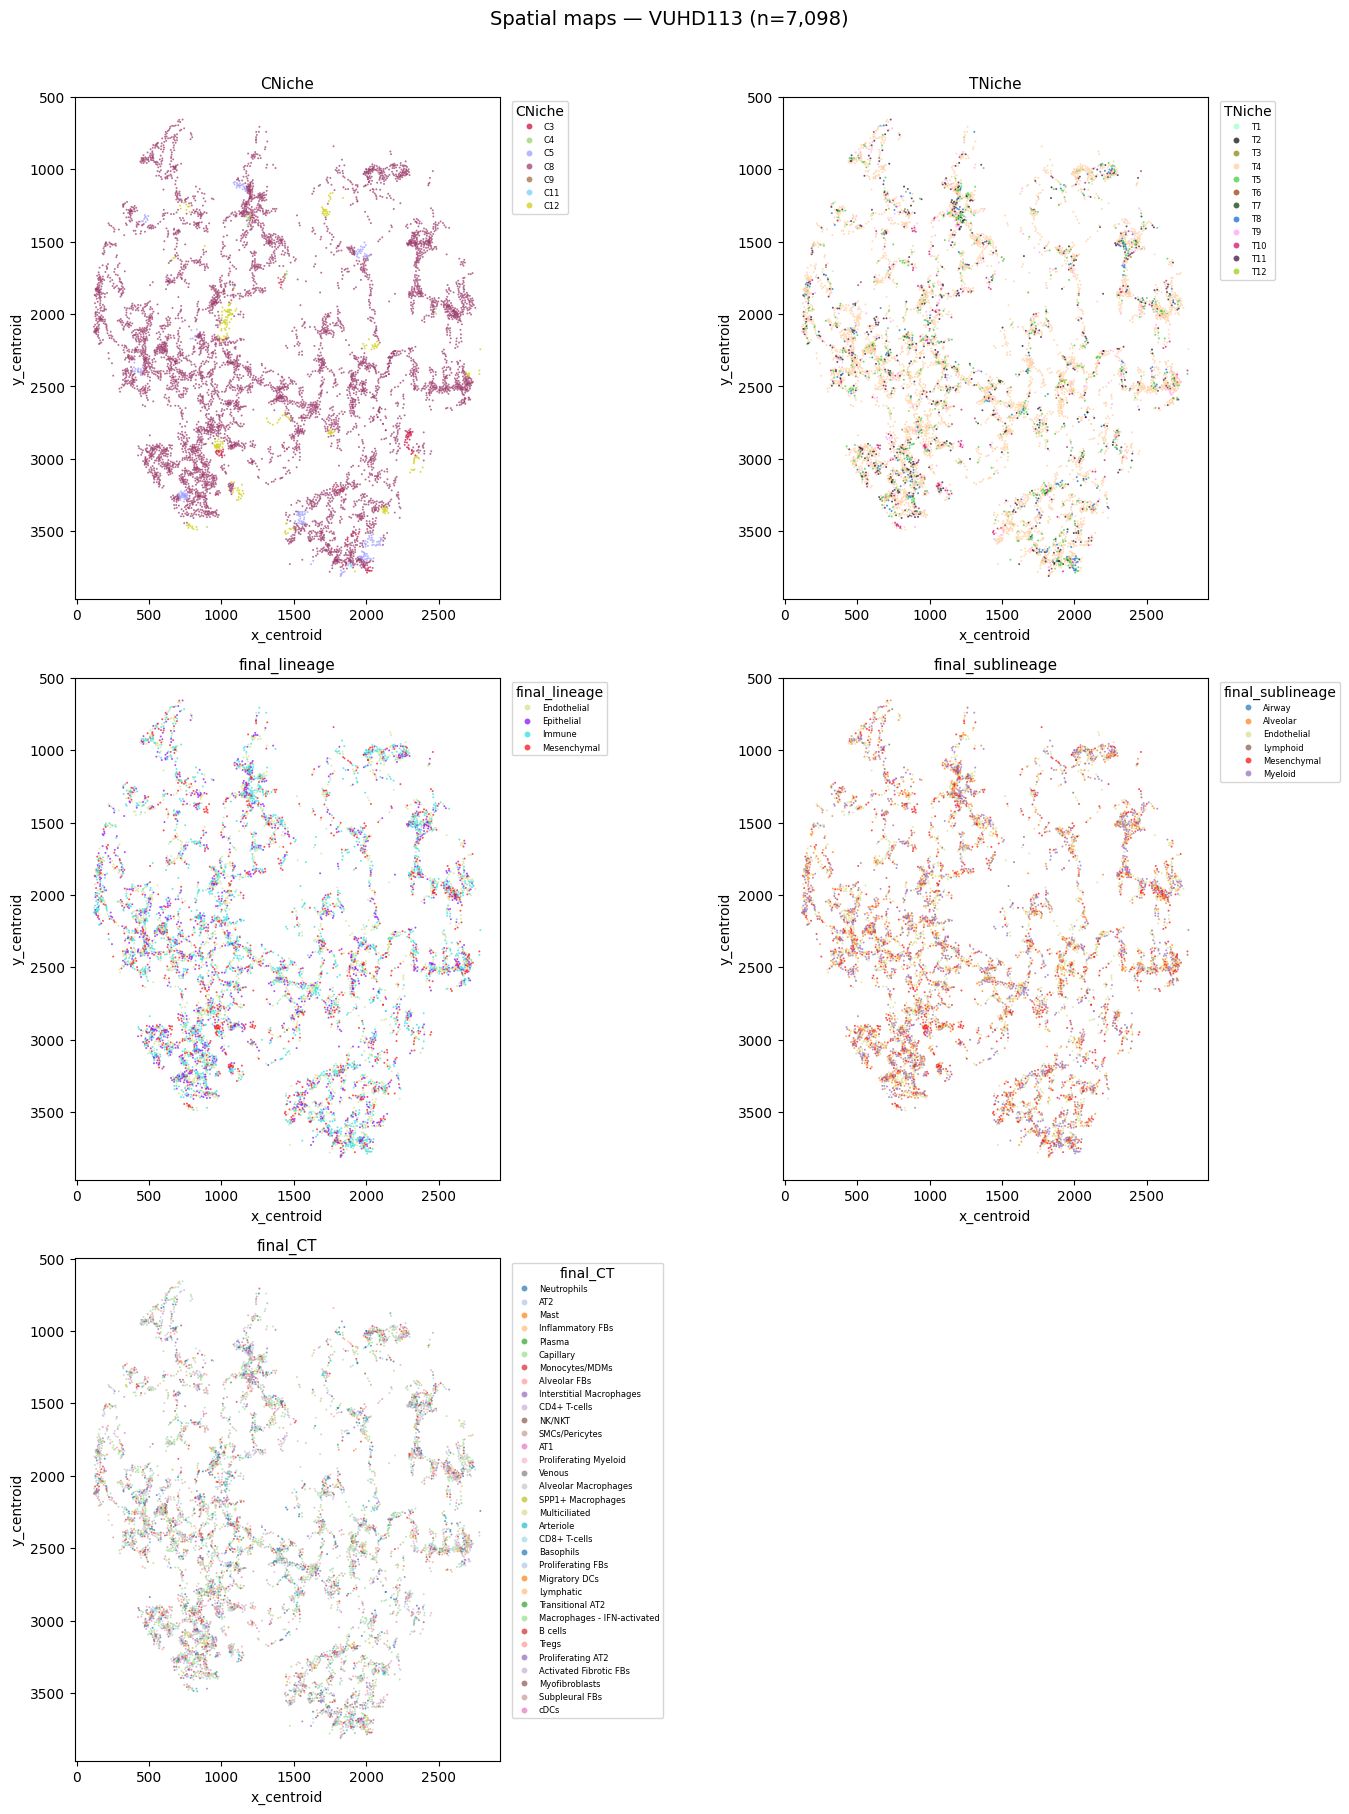

Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUHD113/figures/VUHD113_GT_spatial_maps.jpg

VUILD107MA: n_cells=30,615
Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/figures/VUILD107MA_GT_spatial_maps.jpg


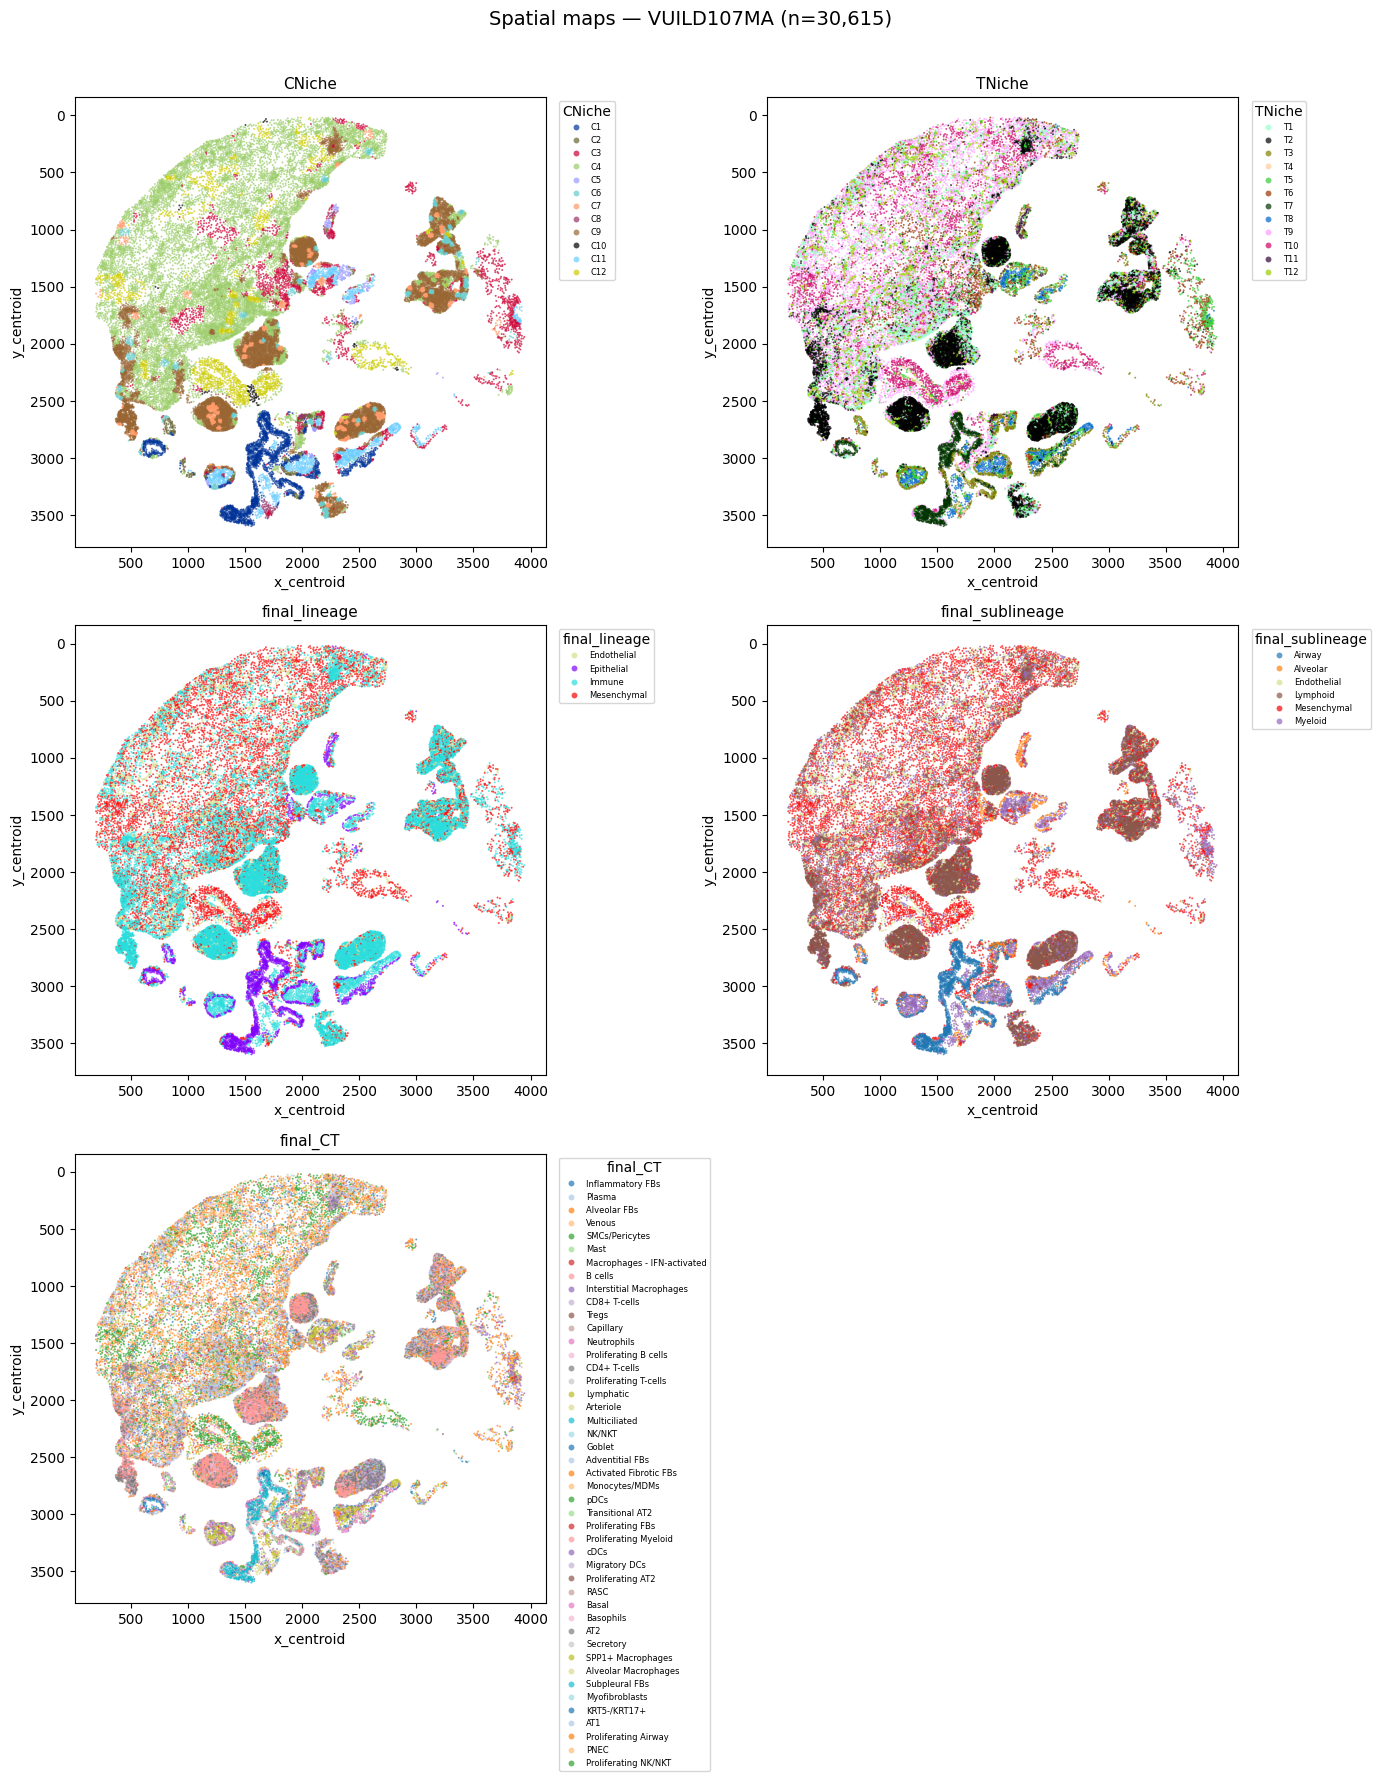

Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/figures/VUILD107MA_GT_spatial_maps.jpg

VUILD102LA: n_cells=24,925
Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD102LA/figures/VUILD102LA_GT_spatial_maps.jpg


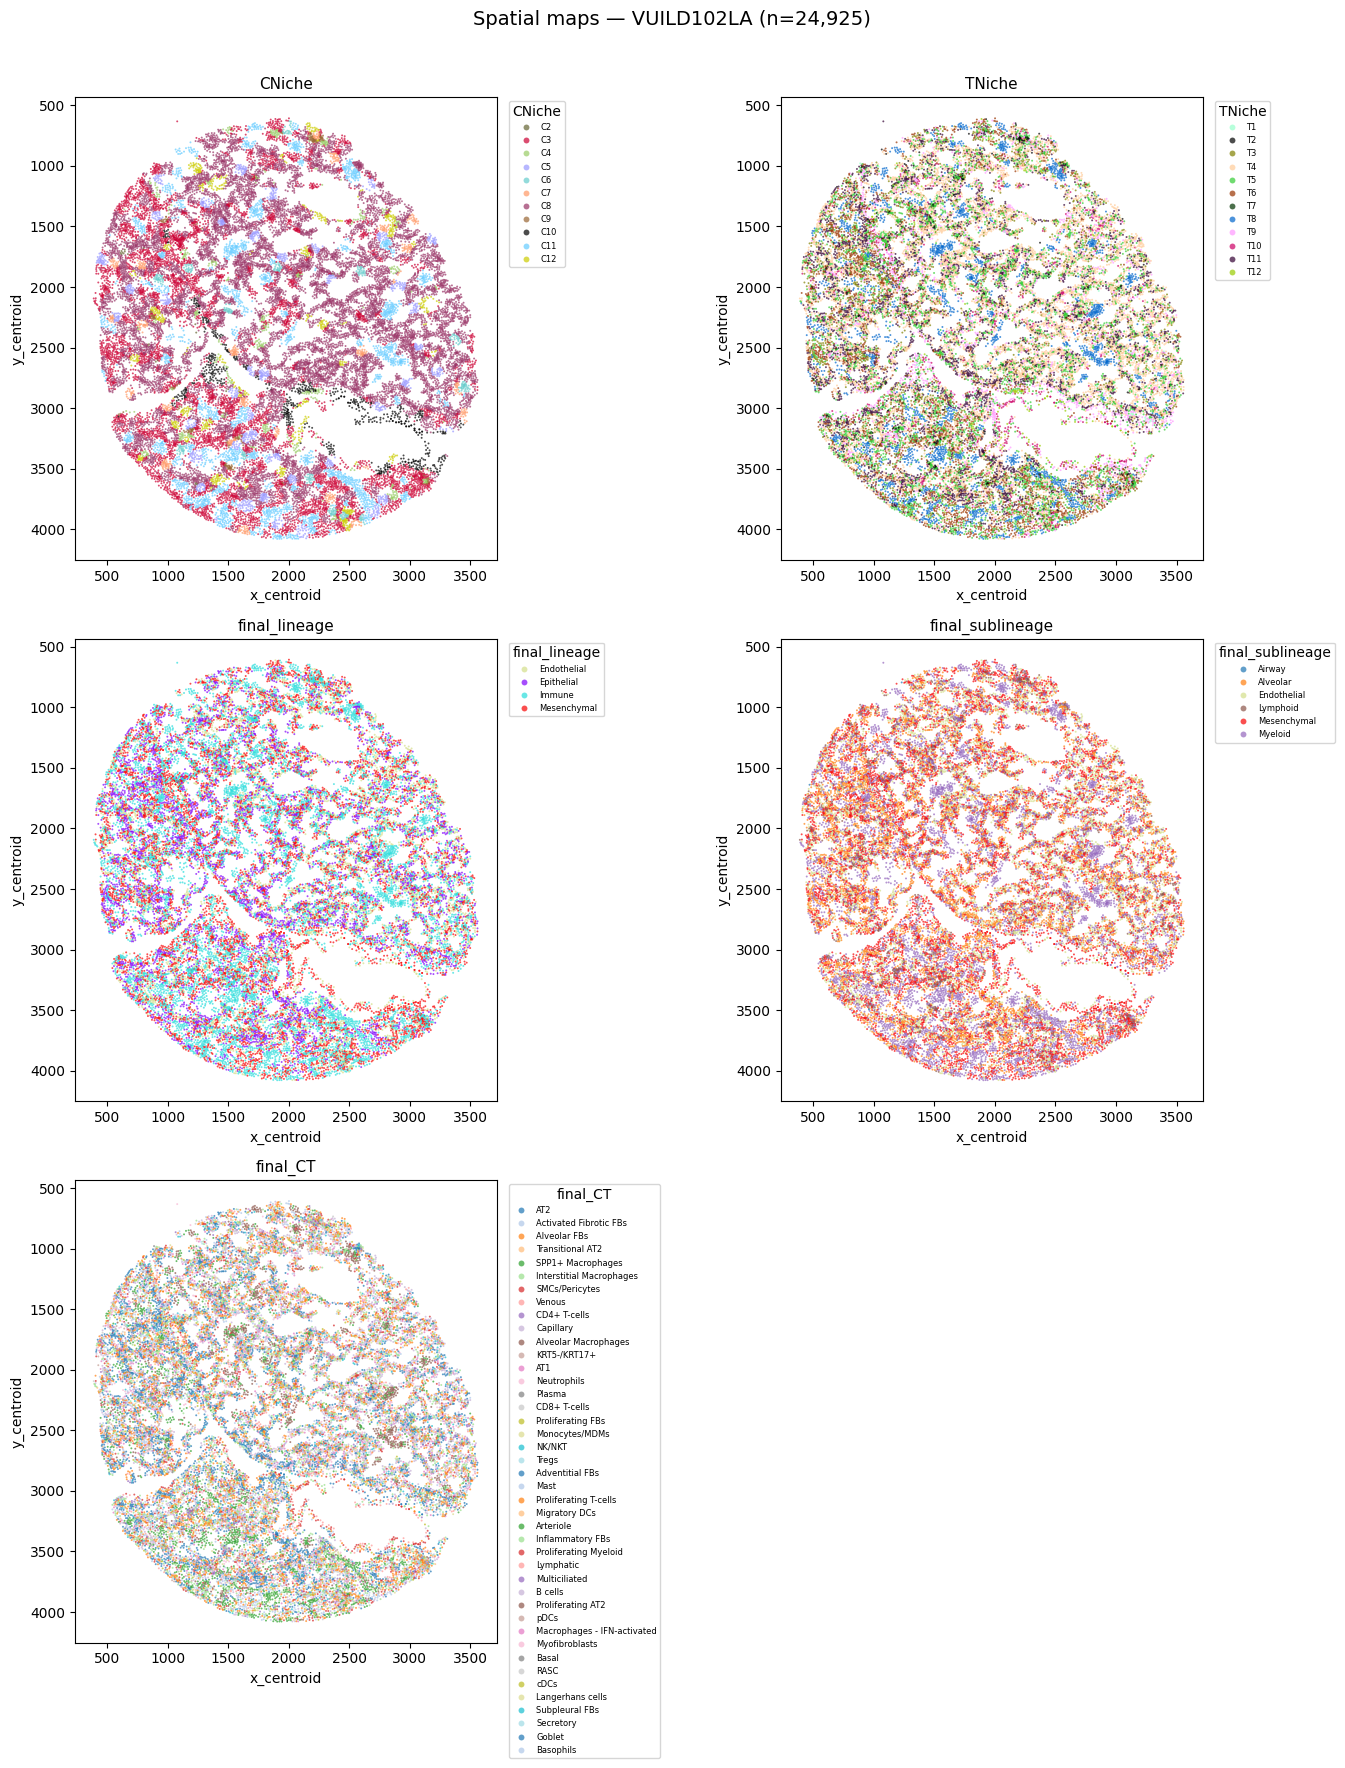

Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD102LA/figures/VUILD102LA_GT_spatial_maps.jpg

VUILD96LA: n_cells=31,727
Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD96LA/figures/VUILD96LA_GT_spatial_maps.jpg


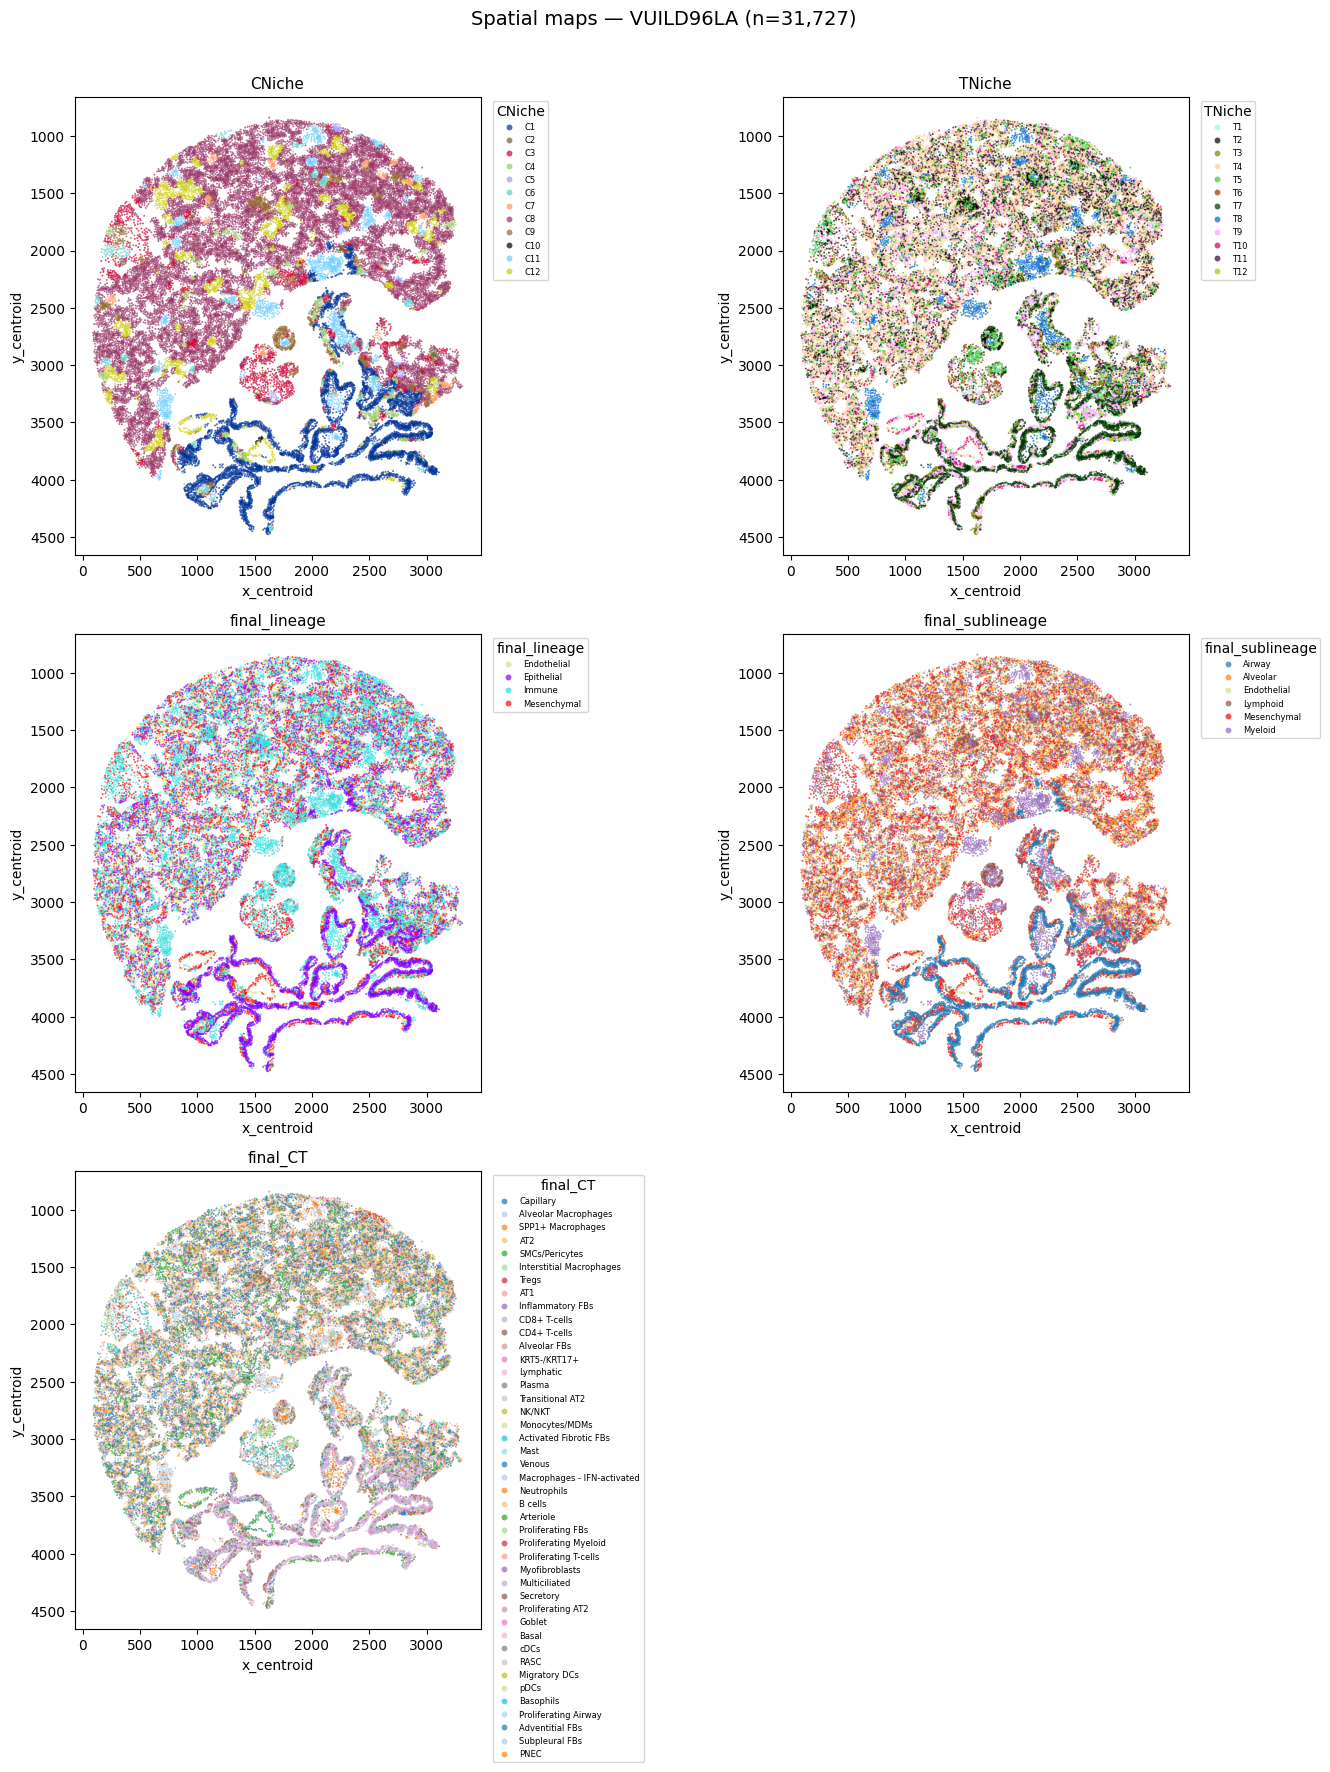

Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD96LA/figures/VUILD96LA_GT_spatial_maps.jpg



In [ ]:
import sys
import importlib
from pathlib import Path

_xenium_dir = Path(f"{path}Hist2Pheno/code/Xenium_lung")
if str(_xenium_dir) not in sys.path:
    sys.path.insert(0, str(_xenium_dir))

import plot_spatial_he_labels
importlib.reload(plot_spatial_he_labels)
from plot_spatial_he_labels import plot_spatial_he_maps, DEFAULT_SPATIAL_COLS

SELECT4_SAMPLES = ['VUHD113', 'VUILD107MA', 'VUILD102LA', 'VUILD96LA']
select4_dir = f"{weiqin_dir}Data/Complete_Cases_Select4"

# 3x2: CNiche, TNiche | final_lineage, final_sublineage | final_CT, (empty)
SPATIAL_COLS = DEFAULT_SPATIAL_COLS

for dataset_select in SELECT4_SAMPLES:
    sample_fig_dir = Path(f"{select4_dir}/{dataset_select}")
    sample_fig_dir.mkdir(parents=True, exist_ok=True)
    out = plot_spatial_he_maps(
        dataset_select,
        labels_he_df=labels_HE_df,
        spatial_cols=SPATIAL_COLS,
        subplot_rows=3,
        subplot_cols=2,
        figsize=(14, 18),
        dpi=300,
        # save_path=sample_fig_dir / f"{dataset_select}_GT_spatial_maps.jpg",
        show=True,
    )
    print(f"Saved: {out}\n")

### Load StarDist results

In [4]:
select4_dir = f'{path}Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4'
dataset_select = 'VUHD113'   # 'VUILD107MA'

import pandas as pd
def load_star_dist_data(select4_dir, dataset_select='VUHD113'):
    """Read StarDist CSV from Complete_Cases_Select4/{sample}/."""
    star_dist_path = f'{select4_dir}/{dataset_select}/{dataset_select}_Float_prob001_nms_03.csv'
    star_dist_df = pd.read_csv(star_dist_path)
    star_dist_df['sample'] = dataset_select
    print(f'[{dataset_select}] StarDist CSV: {star_dist_path}')
    print(f'[{dataset_select}] cell number of star_dist:', star_dist_df.shape)
    return star_dist_df

DATASETS = ['VUHD113', 'VUILD107MA', 'VUILD102LA', 'VUILD96LA']
star_dist_all = {
    s: load_star_dist_data(select4_dir, dataset_select=s)
    for s in DATASETS
}
star_dist_ = star_dist_all[dataset_select]

[VUHD113] StarDist CSV: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUHD113/VUHD113_Float_prob001_nms_03.csv
[VUHD113] cell number of star_dist: (23745, 4)
[VUILD107MA] StarDist CSV: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_Float_prob001_nms_03.csv
[VUILD107MA] cell number of star_dist: (105857, 4)
[VUILD102LA] StarDist CSV: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD102LA/VUILD102LA_Float_prob001_nms_03.csv
[VUILD102LA] cell number of star_dist: (60484, 4)
[VUILD96LA] StarDist CSV: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD96LA/VUILD96LA_Float_prob001_nms_03.csv
[VUILD96LA] cell number of star_dist: (8

In [5]:
star_dist_ = load_star_dist_data(select4_dir, dataset_select=dataset_select)
star_dist_.head()

[VUHD113] StarDist CSV: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUHD113/VUHD113_Float_prob001_nms_03.csv
[VUHD113] cell number of star_dist: (23745, 4)


,centroid_x,centroid_y,probability,sample
0,3678.293251,3560.173920,0.886976,VUHD113
1,3371.622482,3423.181580,0.883140,VUHD113
2,412.258600,795.808817,0.878218,VUHD113
3,3705.858780,3700.159309,0.874990,VUHD113
4,352.317239,705.626997,0.867907,VUHD113


### HE - StarDist

In [7]:
## Load stardist coords (Complete_Cases_Select4/{sample}/)
therapy_data = 'VUHD113'
star_coords_path = f'{select4_dir}/{therapy_data}/{therapy_data}_Float_prob001_nms_03.csv'
star_coords = pd.read_csv(star_coords_path)
print(star_coords_path)
print(star_coords.shape)
star_coords.head()

/home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUHD113/VUHD113_Float_prob001_nms_03.csv
(23745, 3)


,centroid_x,centroid_y,probability
0,3678.293251,3560.173920,0.886976
1,3371.622482,3423.181580,0.883140
2,412.258600,795.808817,0.878218
3,3705.858780,3700.159309,0.874990
4,352.317239,705.626997,0.867907
